<div class="alert alert-danger" role="alert">
    <h1 align="center"><font size = 14>Hands-On Deep Learning</font></h1>
    <h2 align="center"><font size = 5>SGD</font></h2>
    <h3 align="center">Zahra Amini</h3>
    <h1 class="alert-heading">Links:</h1>
    <a href="http://www.youtube.com/@AI2YOU">YouTube</a><br>
    <a href="https://www.linkedin.com/company/ai2you">LinkedIn</a><br>
    <a href="https://github.com/aminizahra/ML_AI2YOU/tree/main">GitHub Repository</a><br>
    <a href="https://zil.ink/zahraamini">Zahra Amini</a><br>
</div>br>
<br>

# Importing the Libraries

In [3]:
import numpy as np
np.random.seed(42)

In [4]:
import matplotlib.pyplot as plt 
import matplotlib.animation as animation 
from matplotlib.animation import PillowWriter

---------------------------------

# Part1

## Single variable

### Defining the function and its derivative

In [9]:
def f(x):            
    return x - x**3    

In [10]:
def fdash(x):
    return 1 - 3*(x**2)

<br>

In [12]:
point = -1   
learning_rate = 0.01     

for i in range(1000):   
    update = - learning_rate * fdash(point) 
    point += update  
    
print(point)        

-0.5773502691896273


------------------------------

### Animation for SGD

In [15]:
point_sgd = [-1]

In [16]:
point = -1        
learning_rate = 0.01     

for i in range(1000):  
    update = - learning_rate * fdash(point)    
    point += update
    
    point_sgd.append(point)
    
print(point)                                           

-0.5773502691896273


<br>                                          

In [18]:
plt.rcParams.update({'font.size': 22})

Text(0.5, 1.0, 'SGD, learning_rate = 0.01')

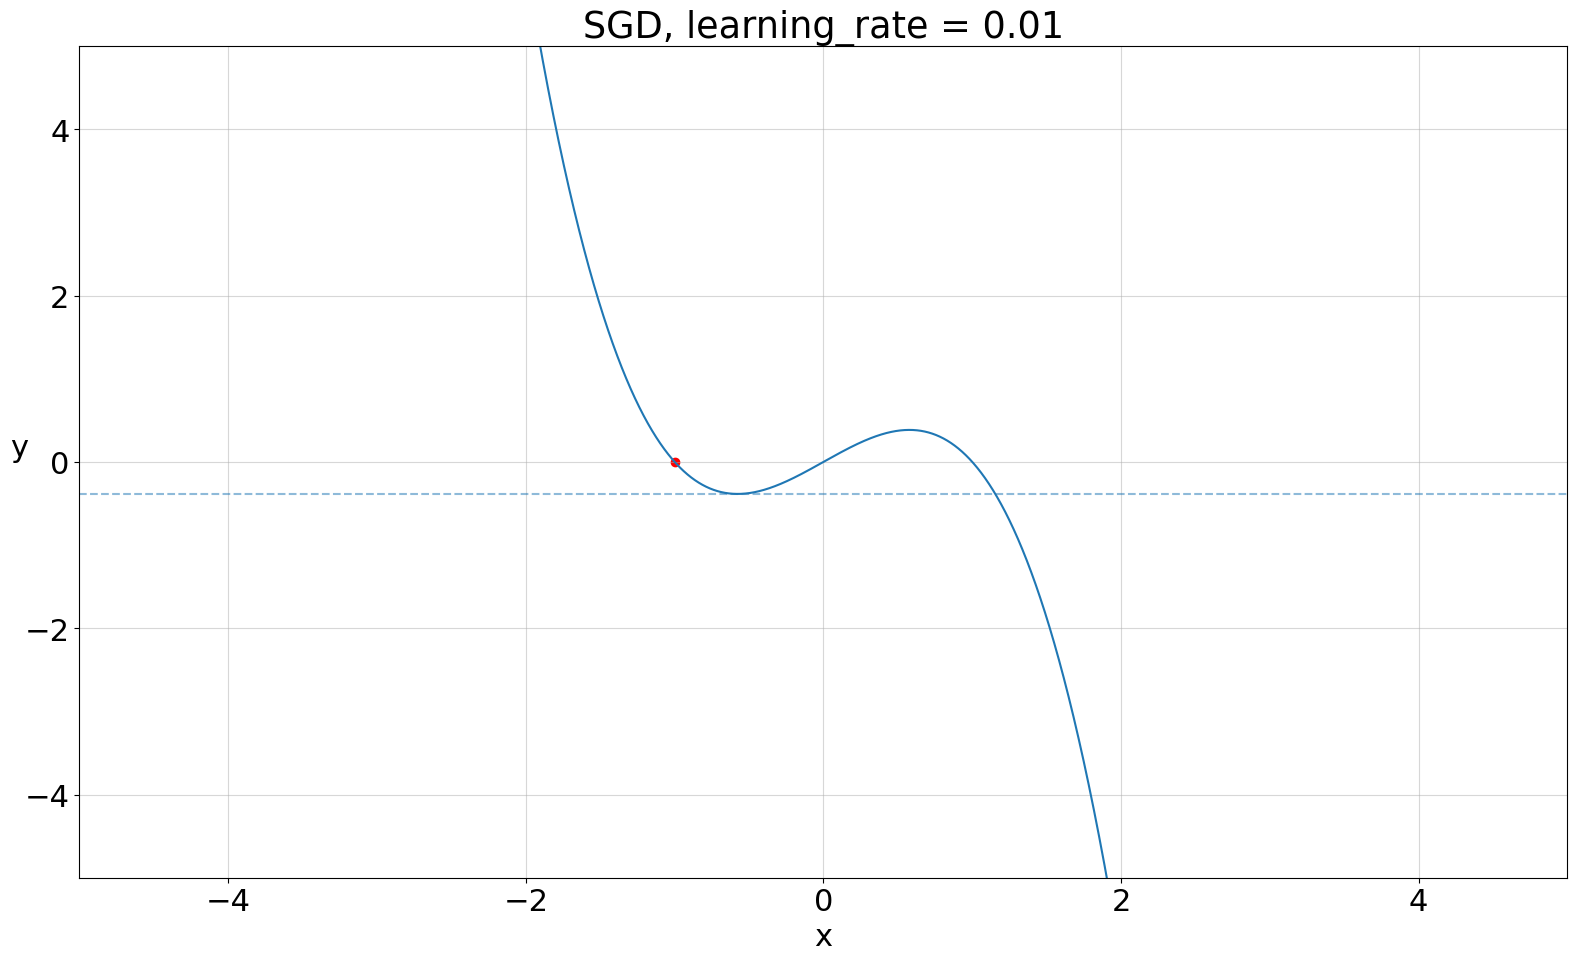

In [19]:
fig = plt.figure(dpi = 100)

fig.set_figheight(10.80)
fig.set_figwidth(19.20)

x_ = np.linspace(-5, 5, 10000)
y_ = f(x_)

ax = plt.axes()
ax.plot(x_, y_)
ax.grid(alpha = 0.5)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel('x')
ax.set_ylabel('y', rotation = 0)
ax.scatter(-1, f(-1), color = 'red')
ax.hlines(f(-0.5773502691896256), -5, 5, linestyles = 'dashed', alpha = 0.5)

ax.set_title('SGD, learning_rate = 0.01')

In [20]:
def animate(i):
    ax.clear()
    ax.plot(x_, y_)
    ax.grid(alpha = 0.5)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('y', rotation = 0)
    ax.hlines(f(-0.5773502691896256), -5, 5, linestyles = 'dashed', alpha = 0.5)
    ax.set_title('SGD, learning_rate = 0.01')
    
    ax.scatter(point_sgd[i], f(point_sgd[i]), color = 'red')

In [21]:
anim = animation.FuncAnimation(fig, animate, frames = 200, interval = 20)

anim.save('2.1 SGD.gif')

MovieWriter ffmpeg unavailable; using Pillow instead.


-------------------------

## Two variables

### Defining the function, partial derivatives and gradient array

In [25]:
def f(x, y):               
    return 2*(x**2) + 2*x*y + 2*(y**2) - 6*x  

In [26]:
def fdash_x(x, y):
    return 4*x + 2*y - 6      

In [27]:
def fdash_y(x, y):
    return 2*x + 4*y            

In [28]:
def gradient(point):
    return np.array([[     fdash_x(point[0][0], point[1][0])     ],
                     [     fdash_y(point[0][0], point[1][0])     ]], dtype = np.float64)

<br>                                          

In [30]:
point = np.array([[   1   ],
                  [   0   ]], dtype = np.float64)

learning_rate = 0.01

for i in range(1000):
    update = - learning_rate * gradient(point)  
    
    point += update
    
point

array([[ 2.],
       [-1.]])

# Part2

## Single variable

### Defining the function and its derivative

In [34]:
# def f(x):            
#     return x - x**3    

In [35]:
# def fdash(x):
#     return 1 - 3*(x**2)

In [36]:
point = -1
learning_rate = 0.01

momentum = 0.9
update = 0

for i in range(1000):
    update = - learning_rate * fdash(point) + momentum * update
    point += update
    
point

-0.5773502691896256

### Animation for SGD with Momentum

In [38]:
plt.rcParams.update({'font.size': 22})

TypeError: f() missing 1 required positional argument: 'y'

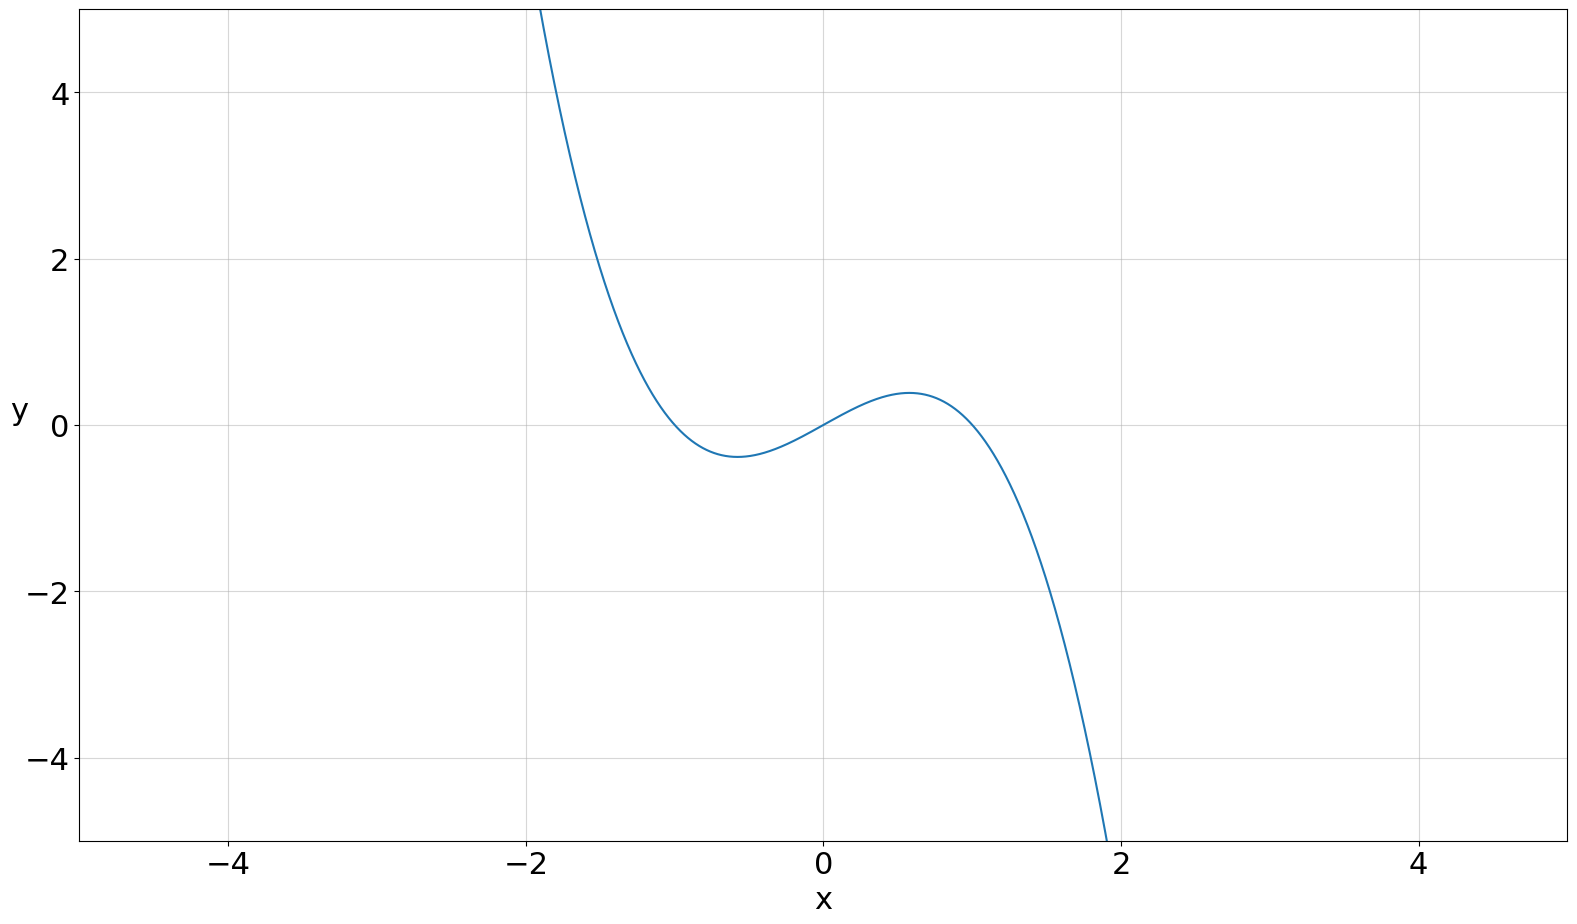

In [39]:
fig = plt.figure(dpi = 100)

fig.set_figheight(10.80)
fig.set_figwidth(19.20)

ax = plt.axes()
ax.plot(x_, y_)
ax.grid(alpha = 0.5)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel('x')
ax.set_ylabel('y', rotation = 0)
ax.scatter(-1, f(-1), color = 'red')
ax.hlines(f(point), -5, 5, linestyles = 'dashed', alpha = 0.5)

ax.set_title('SGD with Momentum, learning_rate = 0.01')

In [ ]:
def animate(i):
    ax.clear()
    ax.plot(x_, y_)
    ax.grid(alpha = 0.5)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('y', rotation = 0)
    ax.hlines(f(-0.5773502691896256), -5, 5, linestyles = 'dashed', alpha = 0.5)
    ax.set_title('SGD with Momentum, learning_rate = 0.01')
    
    ax.scatter(point_sgd_momentum[i], f(point_sgd_momentum[i]), color = 'red')

In [ ]:
anim = animation.FuncAnimation(fig, animate, frames = 200, interval = 20)

anim.save('2.2 SGD with Momentum.gif')

## Two variables

In [ ]:
point = np.array([[   1   ],
                  [   0   ]], dtype = np.float64)

learning_rate = 0.01

momentum = 0.9
update = np.array([[   0   ],
                   [   0   ]], dtype = np.float64)

for i in range(1000):
    update = - learning_rate * gradient(point) + momentum * update
    point += update
    
point

# Part3

## Single variable

In [ ]:
point = -1
learning_rate = 0.01

momentum = 0.9
update = 0

for i in range(1000):
    update = - learning_rate * fdash(point) + momentum * update
    update_ = - learning_rate * fdash(point) + momentum * update
    point += update_
    
point

### Animation for SGD with Nesterov acceleration

In [ ]:
point_sgd_nesterov = [-1]

In [ ]:
point = -1
learning_rate = 0.01

momentum = 0.9
update = 0

for i in range(1000):
    update = - learning_rate * fdash(point) + momentum * update
    update_ = - learning_rate * fdash(point) + momentum * update
    point += update_
    
    point_sgd_nesterov.append(point)
    
point

### SGD with Nesterov acceleration

In [ ]:
plt.rcParams.update({'font.size': 22})

In [ ]:
fig = plt.figure(dpi = 100)

fig.set_figheight(10.80)
fig.set_figwidth(19.20)

ax = plt.axes()
ax.plot(x_, y_)
ax.grid(alpha = 0.5)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel('x')
ax.set_ylabel('y', rotation = 0)
ax.scatter(-1, f(-1), color = 'red')
ax.hlines(f(point), -5, 5, linestyles = 'dashed', alpha = 0.5)

ax.set_title('SGD with Nesterov acceleration, learning_rate = 0.01')

In [ ]:
def animate(i):
    ax.clear()
    ax.plot(x_, y_)
    ax.grid(alpha = 0.5)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('y', rotation = 0)
    ax.hlines(f(-0.5773502691896256), -5, 5, linestyles = 'dashed', alpha = 0.5)
    ax.set_title('SGD with Nesterov acceleration, learning_rate = 0.01')
    
    ax.scatter(point_sgd_nesterov[i], f(point_sgd_nesterov[i]), color = 'red')

In [ ]:
anim = animation.FuncAnimation(fig, animate, frames = 200, interval = 20)

anim.save('2.3 SGD with Nesterov acceleration.gif')

## Two variables

In [ ]:
point = np.array([[   1   ],
                  [   0   ]], dtype = np.float64)

learning_rate = 0.01

momentum = 0.9
update = np.array([[   0   ],
                   [   0   ]], dtype = np.float64)

for i in range(1000):
    update = - learning_rate * gradient(point) + momentum * update
    update_ = - learning_rate * gradient(point) + momentum * update
    point += update_
    
point